In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('tax_returns.csv')

In [5]:
df.head()

,income_declared,work_expense_claim,travel_expense_claim,education_expense,other_deductions,total_deductions,deduction_income_ratio,prior_year_income_delta,prior_year_deduction_delta,refund_requested,filing_method,industry_code,num_dependents,fraud_label
0,73900,7230,2110,3990,2190,15520,0.2100,0.1984,0.0172,7170,self,hospitality,0,0
1,45000,5180,620,2280,1320,9400,0.2089,0.0181,-0.1499,2210,self,retail,3,0
2,92700,7160,1560,3740,2060,14520,0.1566,-0.0278,-0.1344,1910,self,hospitality,2,0
3,79100,24230,2500,1120,1120,28970,0.3662,0.1502,-0.2046,11520,self,transport,0,0
4,63800,15040,2330,3680,720,21770,0.3412,0.1701,0.1752,8470,tax_agent,construction,4,0


[]

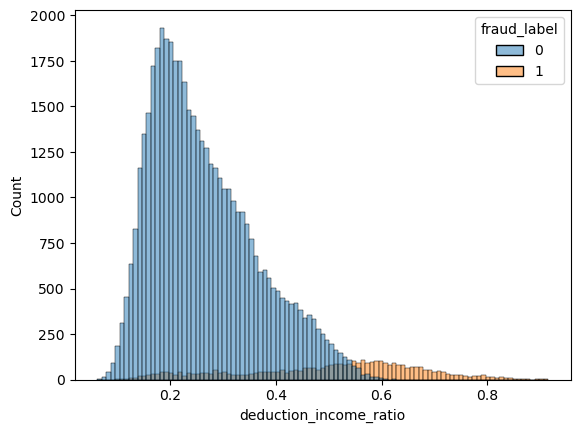

In [6]:
sns.histplot(data = df,x = 'deduction_income_ratio',hue = 'fraud_label' )
plt.plot()

In [7]:
cols = ["work_expense_claim", "travel_expense_claim", "education_expense", "other_deductions"]

In [11]:
claim_expenses = df.groupby('fraud_label')[cols].mean()

<Axes: xlabel='fraud_label'>

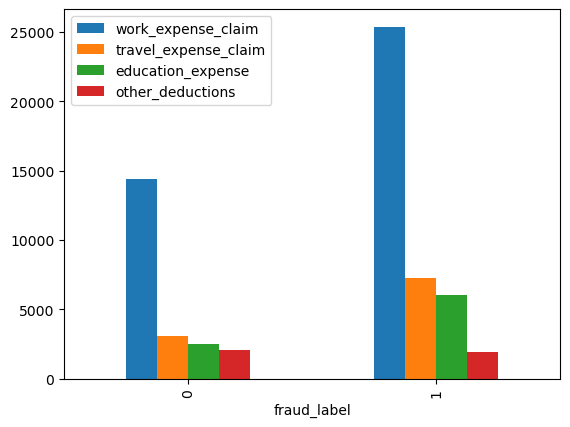

In [13]:
claim_expenses.plot(kind = 'bar')

[]

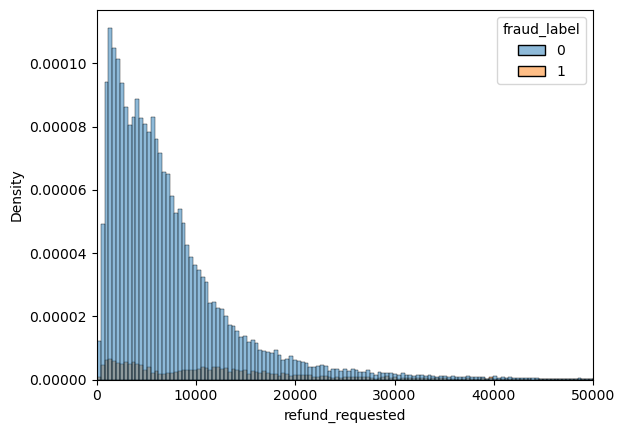

In [33]:
plt.xlim(0,50000)
sns.histplot(data = df,x = 'refund_requested',hue = 'fraud_label',stat = 'density')
plt.plot()

In [17]:
df['fraud_label'].value_counts()

fraud_label
0    46000
1     4000
Name: count, dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   income_declared             50000 non-null  int64  
 1   work_expense_claim          50000 non-null  int64  
 2   travel_expense_claim        50000 non-null  int64  
 3   education_expense           50000 non-null  int64  
 4   other_deductions            50000 non-null  int64  
 5   total_deductions            50000 non-null  int64  
 6   deduction_income_ratio      50000 non-null  float64
 7   prior_year_income_delta     50000 non-null  float64
 8   prior_year_deduction_delta  50000 non-null  float64
 9   refund_requested            50000 non-null  int64  
 10  filing_method               50000 non-null  object 
 11  industry_code               50000 non-null  object 
 12  num_dependents              50000 non-null  int64  
 13  fraud_label                 500

In [21]:
numeric_cols = ['income_declared','work_expense_claim','travel_expense_claim','education_expense','other_deductions','total_deductions','deduction_income_ratio','prior_year_income_delta','prior_year_deduction_delta','refund_requested','num_dependents']

In [24]:
df[numeric_cols].corr()

,income_declared,work_expense_claim,travel_expense_claim,education_expense,other_deductions,total_deductions,deduction_income_ratio,prior_year_income_delta,prior_year_deduction_delta,refund_requested,num_dependents
income_declared,1.000000,0.707079,0.454776,0.514583,0.663277,0.759990,0.010442,-0.009950,0.002741,0.784004,0.001939
work_expense_claim,0.707079,1.000000,0.539879,0.471039,0.462204,0.958331,0.555643,-0.006412,0.257868,0.911861,0.000659
travel_expense_claim,0.454776,0.539879,1.000000,0.278204,0.301703,0.698865,0.479215,0.001528,0.076502,0.654988,-0.001460
education_expense,0.514583,0.471039,0.278204,1.000000,0.338843,0.604352,0.285360,-0.011909,0.071363,0.585706,-0.000352
other_deductions,0.663277,0.462204,0.301703,0.338843,1.000000,0.553981,0.077845,-0.004380,-0.001347,0.559192,-0.003960
total_deductions,0.759990,0.958331,0.698865,0.604352,0.553981,1.000000,0.562562,-0.006616,0.211324,0.954088,-0.000344
deduction_income_ratio,0.010442,0.555643,0.479215,0.285360,0.077845,0.562562,1.000000,0.002326,0.371957,0.440862,0.000347
prior_year_income_delta,-0.009950,-0.006412,0.001528,-0.011909,-0.004380,-0.006616,0.002326,1.000000,0.001706,-0.008222,-0.001086
prior_year_deduction_delta,0.002741,0.257868,0.076502,0.071363,-0.001347,0.211324,0.371957,0.001706,1.000000,0.167130,0.000169
refund_requested,0.784004,0.911861,0.654988,0.585706,0.559192,0.954088,0.440862,-0.008222,0.167130,1.000000,0.000414


(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5]),
 [Text(0.5, 0, 'income_declared'),
  Text(1.5, 0, 'work_expense_claim'),
  Text(2.5, 0, 'travel_expense_claim'),
  Text(3.5, 0, 'education_expense'),
  Text(4.5, 0, 'other_deductions'),
  Text(5.5, 0, 'total_deductions'),
  Text(6.5, 0, 'deduction_income_ratio'),
  Text(7.5, 0, 'prior_year_income_delta'),
  Text(8.5, 0, 'prior_year_deduction_delta'),
  Text(9.5, 0, 'refund_requested'),
  Text(10.5, 0, 'num_dependents')])

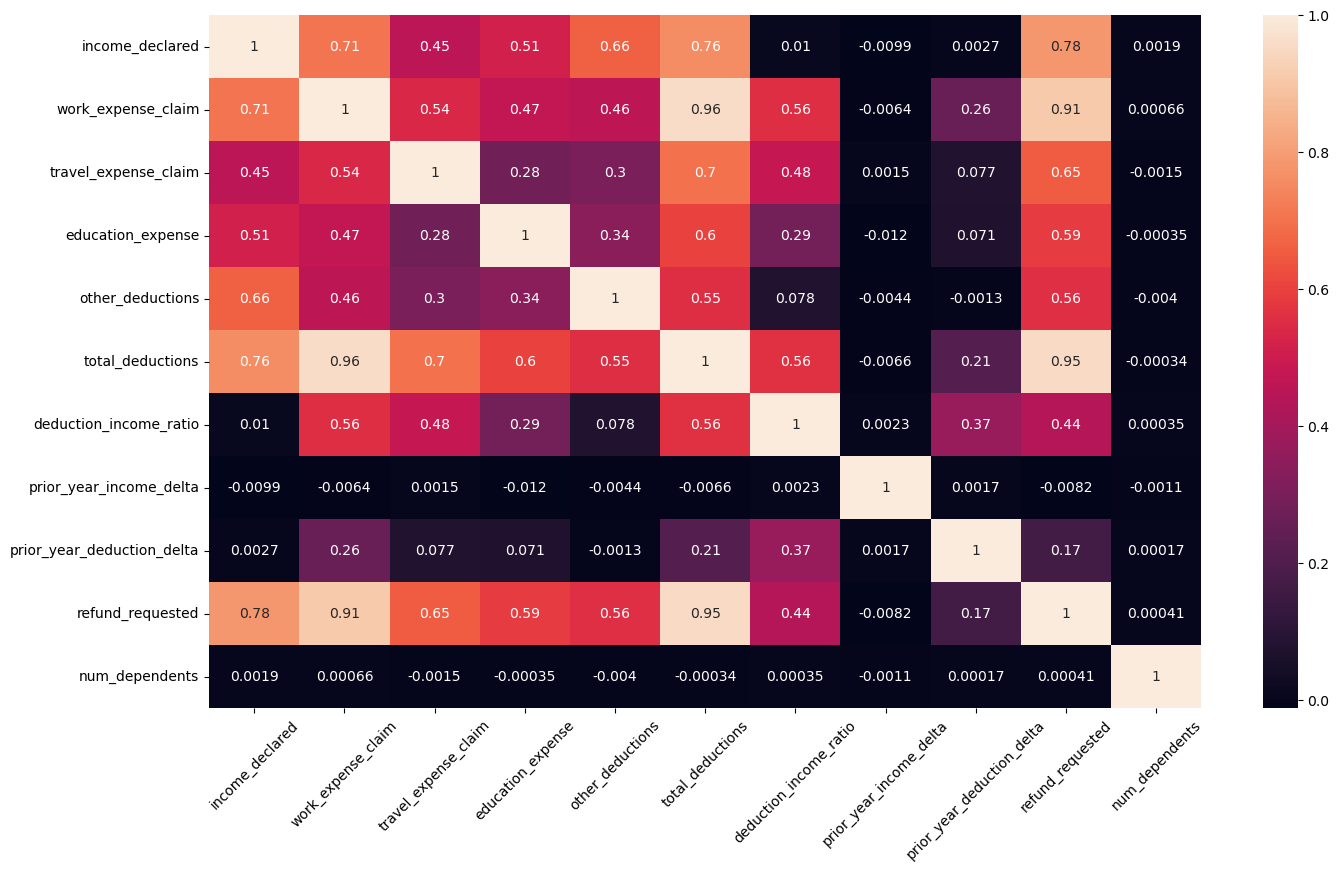

In [31]:
plt.figure(figsize = (16,9))
sns.heatmap(df[numeric_cols].corr(),annot = True)
plt.xticks(rotation = 45)